In [1]:
import numpy as np
import matplotlib.pyplot as plt


def getComplexSignal(frequency,amplitude,st,end,step,phase=0,t0=2e-7):
    time=np.arange(st*1e-9, end*1e-9, step*1e-9) # 1e-9 converts ns to s
    rot= amplitude * np.exp(1j * (2 * np.pi * frequency * (time+t0) + phase))
    return rot


frequencies=6699324335.796245
samples_per_clk=16 # 16 samples per clock cycle
st=20105 #Vary from circuit to circuit # in ns
CSTROBE_DELAY=2 #delay in clock cycles related to control strobe
QCLK_DELAY=4 #delay in clock cycles related to qubit
PHASEIN_DELAY=1 #additional delay for phase input 
phase=6.173789022938911  # base phase offset from calibration
CLK_CYCLE=2 # one clock cycle is 2 ns
PHASE_RST_DELAY=9
#convert start index to sample index
start_time = samples_per_clk*st\
    + samples_per_clk*(CSTROBE_DELAY + QCLK_DELAY + PHASEIN_DELAY) # convert sum of delay cycles to sample index

phases = phase + 2*np.pi*(CLK_CYCLE/samples_per_clk)\
        *1.e-9*(start_time - samples_per_clk*(PHASE_RST_DELAY))*frequencies # time difference between phase reset and measurement start

amplitude=1 


dlo = getComplexSignal(frequencies, amplitude, st=0, end=4096, step=0.5, phase=phases, t0=0) # time goes from 0 to 4096ns in steps of 0.5ns
# 4096/0.5 = 8192 samples, t0 is an extra time offset, default is 200ns, here set to 0




# dlo_int=np.ceil(dlo.real*((2**15)-1)) + 1j*(np.ceil(dlo.imag*((2**15)-1)))


# plt.plot(dlo.real[:10])
# plt.plot(dlo.imag[:10])
# plt.xlabel('Sample Index')
# plt.ylabel('Amplitude')
# plt.show()

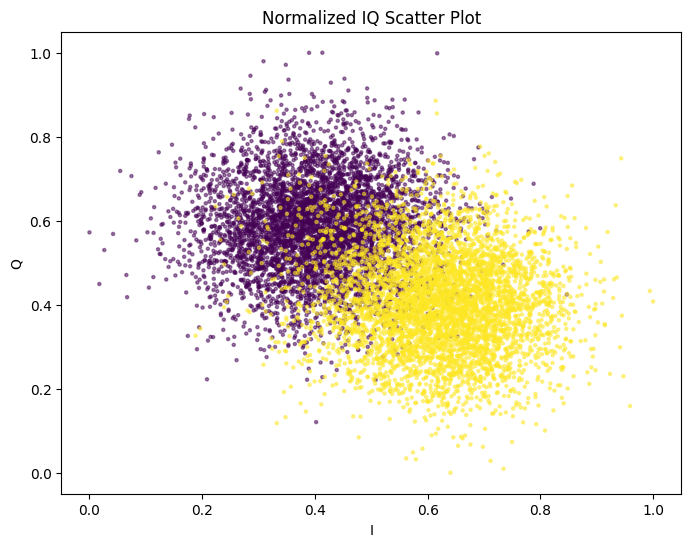

In [2]:
DATA_DIR = "data/"
conj = False
raw0 = np.load(DATA_DIR + "Q3_raw_state0.npy")
raw1 = np.load(DATA_DIR + "Q3_raw_state1.npy")


raw0_f = raw0.astype(np.float64)
raw1_f = raw1.astype(np.float64)

if conj:
    dlo_conj = np.conj(dlo)[None, :]
else:
    dlo_conj = dlo[None, :]


# demodulation
ADC_mix0 = raw0_f * dlo_conj
ADC_mix1 = raw1_f * dlo_conj
# accumulation
ADC_acc0 = ADC_mix0.sum(axis=1)
ADC_acc1 = ADC_mix1.sum(axis=1)

# get I and Q 
I0 = ADC_acc0.real
Q0 = ADC_acc0.imag

I1 = ADC_acc1.real
Q1 = ADC_acc1.imag

I = np.concatenate([I0, I1])
Q = np.concatenate([Q0, Q1])

# make labels, shape (10000, )
y = np.concatenate([np.zeros_like(I0, dtype=np.int64), np.ones_like(I1, dtype=np.int64)])
# make data matrix, each row is the coordinate of (I, Q), size (10000, 2)
X = np.stack([I, Q], axis=1)

# TODO: store mean for later use
# normalize data to [0, 1], as in the paper
mean = X.mean(axis=0, keepdims=True)
X_centered = X - mean
# take min, max for I and Q separately
xmin = X_centered.min(axis=0, keepdims=True)
xmax = X_centered.max(axis=0, keepdims=True)
scale = xmax - xmin
X_norm = (X_centered - xmin)/scale


# visualize normalized data
I_norm = X_norm[:, 0]
Q_norm = X_norm[:, 1]
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(I_norm, Q_norm, c=y, s=5, alpha=0.5)
ax.set_xlabel('I')
ax.set_ylabel('Q')
ax.set_title('Normalized IQ Scatter Plot')
plt.show()

In [3]:
import torch 
from torch.utils.data import Dataset, DataLoader 
import torch.nn as nn
import torch.nn.functional as F 
import torch.optim as optim
import random
import torch.nn.init as init
import copy 
def init_weights_he(m):
    # This will be called on every submodule when you do model.apply(...)
    if isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear) or isinstance(m, nn.GRU):
        init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            init.zeros_(m.bias)

PATIENCE = 10
SEED = 59
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")





split_ratio = 0.6

N = X_norm.shape[0]
indices = np.arange(N)
np.random.shuffle(indices)

n_train = int(N * split_ratio)

train_idx = indices[:n_train]
test_idx  = indices[n_train:]
batch_size = 64
num_epochs = 200
learning_rate = 1e-3
class IQDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32) # (N, 2)
        self.y = torch.tensor(y, dtype=torch.float32) # (N, ) 
        self.y = self.y.view(-1, 1)   # (N, 1)

    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
        
class QubiCMLNN(nn.Module):
    def __init__(self):
        super(QubiCMLNN, self).__init__()
        self.l1 = nn.Linear(2, 8)
        self.l2 = nn.Linear(8, 4)
        self.l3 = nn.Linear(4, 1)

    def forward(self, x):
        x = F.relu(self.l1(x))
        x = F.relu(self.l2(x))
        x = torch.sigmoid(self.l3(x))
        return x
    
def evaluate_model(model, test_loader):
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            probs = model(X_batch)            # (batch, 1), sigmoid outputs in [0,1]
            all_probs.append(probs.cpu())
            all_labels.append(y_batch.cpu())

    # concatenate all batches
    all_probs  = torch.cat(all_probs, dim=0).view(-1)   # shape (N_test,)
    all_labels = torch.cat(all_labels, dim=0).view(-1)  # shape (N_test,)

    # overall accuracy
    preds = (all_probs > 0.5).float()
    overall_correct = (preds == all_labels).sum().item()
    overall_total   = all_labels.numel()
    test_acc = overall_correct / overall_total

    # masks by true class
    mask_0 = (all_labels == 0)
    mask_1 = (all_labels == 1)

    total_0 = mask_0.sum().item()
    total_1 = mask_1.sum().item()

    if total_0 == 0 or total_1 == 0:
        print("WARNING: one of the classes is missing from the test set!")
        F_00 = float("nan")
        F_11 = float("nan")
        F_avg = float("nan")
    else:
        correct_00 = (preds[mask_0] == 0).sum().item()
        correct_11 = (preds[mask_1] == 1).sum().item()

        F_00 = correct_00 / total_0   # P(predict=0 | true=0)
        F_11 = correct_11 / total_1   # P(predict=1 | true=1)
        F_avg = 0.5 * (F_00 + F_11)
    return test_acc, F_00, F_11, F_avg

 


In [4]:
X_train, X_test = X_norm[train_idx], X_norm[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
train_ds = IQDataset(X_train, y_train)
test_ds = IQDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)


model = QubiCMLNN().to(device)
model.apply(init_weights_he)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # lr not specified in paper
best_mlp_loss = float("inf")
best_mlp_epoch = -1
best_mlp_metrics = None
best_state_dict = None
patience_cnt = 0

for epoch in range(num_epochs):  # up to 1000 epochs
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(train_ds)

    # optional simple "until convergence" check
    print(f"Epoch {epoch+1}, loss = {epoch_loss:.4f}")
    # you could stop early if loss plateaus; the paper just says "or until loss converged".
    test_acc, F_00, F_11, F_avg = evaluate_model(model, test_loader)
    print(f"Test accuracy: {test_acc:.4f}, F_00: {F_00:.4f}, F_11: {F_11:.4f}, F_avg: {F_avg:.4f}")
    if epoch_loss < best_mlp_loss:
        best_mlp_loss = epoch_loss
        best_mlp_epoch = epoch
        best_mlp_metrics = (test_acc, F_00, F_11, F_avg)
        best_state_dict = copy.deepcopy(model.state_dict())
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break
if best_mlp_metrics is not None:
    print(f"Best MLP model at epoch {best_mlp_epoch+1} with loss {best_mlp_loss:.4f}")
    test_acc, F_00, F_11, F_avg = best_mlp_metrics
    print(f"Best MLP Test accuracy: {test_acc:.4f}, F_00: {F_00:.4f}, F_11: {F_11:.4f}, F_avg: {F_avg:.4f}")
    model.load_state_dict(best_state_dict)

Epoch 1, loss = 0.6805
Test accuracy: 0.6885, F_00: 0.9904, F_11: 0.3902, F_avg: 0.6903
Epoch 2, loss = 0.6645
Test accuracy: 0.6963, F_00: 0.9920, F_11: 0.4041, F_avg: 0.6980
Epoch 3, loss = 0.6432
Test accuracy: 0.7175, F_00: 0.9899, F_11: 0.4483, F_avg: 0.7191
Epoch 4, loss = 0.6142
Test accuracy: 0.7728, F_00: 0.9869, F_11: 0.5611, F_avg: 0.7740
Epoch 5, loss = 0.5798
Test accuracy: 0.8205, F_00: 0.9804, F_11: 0.6625, F_avg: 0.8215
Epoch 6, loss = 0.5427
Test accuracy: 0.8535, F_00: 0.9653, F_11: 0.7430, F_avg: 0.8542
Epoch 7, loss = 0.5072
Test accuracy: 0.8460, F_00: 0.9728, F_11: 0.7207, F_avg: 0.8468
Epoch 8, loss = 0.4749
Test accuracy: 0.8585, F_00: 0.9638, F_11: 0.7545, F_avg: 0.8591
Epoch 9, loss = 0.4420
Test accuracy: 0.8848, F_00: 0.9235, F_11: 0.8464, F_avg: 0.8850
Epoch 10, loss = 0.3409
Test accuracy: 0.8895, F_00: 0.9095, F_11: 0.8698, F_avg: 0.8896
Epoch 11, loss = 0.2982
Test accuracy: 0.8890, F_00: 0.8934, F_11: 0.8847, F_avg: 0.8890
Epoch 12, loss = 0.2814
Test a

0.9130, 0.8728 

# CNN

In [5]:
class TimeSeriesIQDataset(Dataset):
    def __init__(self, X, y):
        # X: (N, 2, 8192), y: (N,)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)  # (N, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def min_max_normalize(X):
    xmin = X.min(axis=(0, 2), keepdims=True)
    xmax = X.max(axis=(0, 2), keepdims=True)

    scale = xmax - xmin
    scale[scale == 0] = 1.0  # prevent division by zero

    X_norm = (X - xmin) / scale
    return X_norm

def std_normalize(X):
    mean = X.mean(axis=(0, 2), keepdims=True)
    std = X.std(axis=(0, 2), keepdims=True)

    std[std == 0] = 1.0  # prevent division by zero

    X_norm = (X - mean) / std
    return X_norm



class SmallReadoutCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(2, 16, kernel_size=5, stride=4, padding=2)   # 8192 -> 2048
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, stride=4, padding=2)  # 2048 -> 512

        # keep 4 pooled regions instead of 1
        self.gap = nn.AdaptiveAvgPool1d(8)   # 512 -> 8

        self.fc1 = nn.Linear(32 * 8, 64)     # 256 -> 32
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.conv1(x))   # (B, 16, 2048)
        x = F.relu(self.conv2(x))   # (B, 32, 512)
        x = self.gap(x)             # (B, 32, 8)
        x = x.view(x.size(0), -1)   # (B, 256)
        x = F.relu(self.fc1(x))     # (B, 64)
        logits = self.fc2(x)        # (B, 1)
        return logits

def evaluate_cnn_model(model, test_loader):
    model.eval()
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)              # (B, 1)
            all_logits.append(logits.cpu())
            all_labels.append(y_batch.cpu())

    all_logits  = torch.cat(all_logits, dim=0).view(-1)   # (N_test,)
    all_labels  = torch.cat(all_labels, dim=0).view(-1)   # (N_test,)

    probs = torch.sigmoid(all_logits)                     # (N_test,)
    preds = (probs > 0.5).float()                         # (N_test,)

    # overall accuracy
    overall_correct = (preds == all_labels).sum().item()
    overall_total   = all_labels.numel()
    test_acc = overall_correct / overall_total

    # per-class fidelities
    mask_0 = (all_labels == 0)
    mask_1 = (all_labels == 1)

    total_0 = mask_0.sum().item()
    total_1 = mask_1.sum().item()

    if total_0 == 0 or total_1 == 0:
        print("WARNING: one of the classes is missing from the test set!")
        F_00 = float("nan")
        F_11 = float("nan")
        F_avg = float("nan")
    else:
        correct_00 = (preds[mask_0] == 0).sum().item()
        correct_11 = (preds[mask_1] == 1).sum().item()

        F_00 = correct_00 / total_0   # P(pred=0 | true=0)
        F_11 = correct_11 / total_1   # P(pred=1 | true=1)
        F_avg = 0.5 * (F_00 + F_11) 
    return test_acc, F_00, F_11, F_avg

In [6]:
X_complex = np.concatenate([ADC_mix0, ADC_mix1], axis=0)


X_real = X_complex.real
X_imag = X_complex.imag
X_cnn = np.stack([X_real, X_imag], axis=1)  # shape (N, 2, 8192)

y = np.concatenate([np.zeros(ADC_mix0.shape[0], dtype=np.int64), np.ones(ADC_mix1.shape[0], dtype=np.int64)]) # (N, )


X_cnn_norm = std_normalize(X_cnn)

X_cnn_train, X_cnn_test = X_cnn_norm[train_idx], X_cnn_norm[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

cnn_train_ds = TimeSeriesIQDataset(X_cnn_train, y_train)
cnn_test_ds = TimeSeriesIQDataset(X_cnn_test, y_test)

cnn_batch_size = 64
cnn_train_loader = DataLoader(cnn_train_ds, batch_size=cnn_batch_size, shuffle=True)
cnn_test_loader = DataLoader(cnn_test_ds, batch_size=cnn_batch_size, shuffle=False)

In [7]:
from tqdm.notebook import tqdm
cnn_model = SmallReadoutCNN().to(device)
cnn_model.apply(init_weights_he)
cnn_criterion = nn.BCEWithLogitsLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=learning_rate)  
best_cnn_loss = float("inf")
best_cnn_epoch = -1
best_cnn_metrics = None
best_state_dict = None
patience_cnt = 0
for epoch in tqdm(range(100)):
    cnn_model.train()
    running_loss = 0.0
    for X_batch, y_batch in cnn_train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        cnn_optimizer.zero_grad()
        logits = cnn_model(X_batch)
        loss = cnn_criterion(logits, y_batch)
        loss.backward()
        cnn_optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(cnn_train_ds)

    print(f"Epoch {epoch+1}, CNN loss = {epoch_loss:.4f}")
    test_acc, F_00, F_11, F_avg = evaluate_cnn_model(cnn_model, cnn_test_loader)
    print(f"CNN Test accuracy: {test_acc:.4f}, F_00: {F_00:.4f}, F_11: {F_11:.4f}, F_avg: {F_avg:.4f}")

    if epoch_loss < best_cnn_loss:
        best_cnn_loss = epoch_loss
        best_cnn_epoch = epoch
        best_cnn_metrics = (test_acc, F_00, F_11, F_avg)
        best_state_dict = copy.deepcopy(cnn_model.state_dict())
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

if best_cnn_metrics is not None:
    print(f"Best CNN model at epoch {best_cnn_epoch+1} with loss {best_cnn_loss:.4f}")
    test_acc, F_00, F_11, F_avg = best_cnn_metrics
    print(f"Best CNN Test accuracy: {test_acc:.4f}, F_00: {F_00:.4f}, F_11: {F_11:.4f}, F_avg: {F_avg:.4f}")
    cnn_model.load_state_dict(best_state_dict)


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1, CNN loss = 0.6812
CNN Test accuracy: 0.6525, F_00: 0.3058, F_11: 0.9950, F_avg: 0.6504
Epoch 2, CNN loss = 0.4193
CNN Test accuracy: 0.9320, F_00: 0.8924, F_11: 0.9712, F_avg: 0.9318
Epoch 3, CNN loss = 0.1670
CNN Test accuracy: 0.9657, F_00: 0.9859, F_11: 0.9458, F_avg: 0.9659
Epoch 4, CNN loss = 0.1417
CNN Test accuracy: 0.9603, F_00: 0.9547, F_11: 0.9657, F_avg: 0.9602
Epoch 5, CNN loss = 0.1244
CNN Test accuracy: 0.9692, F_00: 0.9849, F_11: 0.9538, F_avg: 0.9693
Epoch 6, CNN loss = 0.1227
CNN Test accuracy: 0.9692, F_00: 0.9759, F_11: 0.9627, F_avg: 0.9693
Epoch 7, CNN loss = 0.1162
CNN Test accuracy: 0.9683, F_00: 0.9738, F_11: 0.9627, F_avg: 0.9683
Epoch 8, CNN loss = 0.1141
CNN Test accuracy: 0.9712, F_00: 0.9804, F_11: 0.9622, F_avg: 0.9713
Epoch 9, CNN loss = 0.1101
CNN Test accuracy: 0.9725, F_00: 0.9874, F_11: 0.9578, F_avg: 0.9726
Epoch 10, CNN loss = 0.1116
CNN Test accuracy: 0.9670, F_00: 0.9930, F_11: 0.9414, F_avg: 0.9672
Epoch 11, CNN loss = 0.1080
CNN Test ac

0.9849, 0.9548

# PCA + MLP

In [8]:
from sklearn.decomposition import PCA

class PCAFeatureDataset(Dataset):
    def __init__(self, X, y):
        # X: (N, K), y: (N,)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)  # (N, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
class PCANet(nn.Module):
    def __init__(self, in_dim):
        super(PCANet, self).__init__()
        self.l1 = nn.Linear(in_dim, 8)
        self.l2 = nn.Linear(8, 4)
        self.l3 = nn.Linear(4, 1)

    def forward(self, x):
        x = F.relu(self.l1(x))
        x = F.relu(self.l2(x))
        x = torch.sigmoid(self.l3(x))
        return x

In [9]:
ADC_mix = np.concatenate([ADC_mix0, ADC_mix1], axis=0)
y = np.concatenate([np.zeros(ADC_mix0.shape[0], dtype=np.int64), np.ones(ADC_mix1.shape[0], dtype=np.int64)])
DS = 1

ADC_mix_ds = ADC_mix[:, ::DS]  

T_ds = ADC_mix_ds.shape[1] 

I = ADC_mix_ds.real
Q = ADC_mix_ds.imag

X_pca = np.concatenate([I, Q], axis=1)  # shape (N, 2, T_ds)




K = 8

pca = PCA(n_components=K, svd_solver='randomized', whiten=False, random_state=SEED)
Z_features = pca.fit_transform(X_pca)  # shape (N, K)

z_mean = Z_features.mean(axis=0, keepdims=True)
z_std  = Z_features.std(axis=0, keepdims=True)
z_std[z_std == 0] = 1.0

Z_norm = (Z_features - z_mean) / z_std

Z_train_norm, Z_test_norm = Z_norm[train_idx], Z_norm[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

pca_train_ds = PCAFeatureDataset(Z_train_norm, y_train)
pca_test_ds  = PCAFeatureDataset(Z_test_norm, y_test)
pca_train_loader = DataLoader(pca_train_ds, batch_size=batch_size, shuffle=True)
pca_test_loader  = DataLoader(pca_test_ds, batch_size=batch_size, shuffle=False)

In [10]:
pca_model = PCANet(in_dim=K).to(device)
pca_model.apply(init_weights_he)
pca_criterion = nn.BCELoss()
pca_optimizer = optim.Adam(pca_model.parameters(), lr=learning_rate)
best_pca_loss = float("inf")
best_epoch = -1
best_pca_metrics = None
best_state_dict = None
patience_cnt = 0

for epoch in tqdm(range(num_epochs)):
    pca_model.train()
    running_loss = 0.0
    for X_batch, y_batch in pca_train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        pca_optimizer.zero_grad()
        y_pred = pca_model(X_batch)
        loss = pca_criterion(y_pred, y_batch)
        loss.backward()
        pca_optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(pca_train_ds)

    print(f"Epoch {epoch+1}, PCA loss = {epoch_loss:.4f}")
    test_acc, F_00, F_11, F_avg = evaluate_model(pca_model, pca_test_loader)
    print(f"PCA Test accuracy: {test_acc:.4f}, F_00: {F_00:.4f}, F_11: {F_11:.4f}, F_avg: {F_avg:.4f}") 
    if epoch_loss < best_pca_loss:
        best_pca_loss = epoch_loss
        best_epoch = epoch
        best_pca_metrics = (test_acc, F_00, F_11, F_avg)
        best_state_dict = copy.deepcopy(pca_model.state_dict())
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break
if best_pca_metrics is not None:
    test_acc, F_00, F_11, F_avg = best_pca_metrics
    print(f"Best PCA model at epoch {best_epoch+1}, Test accuracy: {test_acc:.4f}, F_00: {F_00:.4f}, F_11: {F_11:.4f}, F_avg: {F_avg:.4f}")# load best model state
    pca_model.load_state_dict(best_state_dict)

  0%|          | 0/200 [00:00<?, ?it/s]

Epoch 1, PCA loss = 0.6737
PCA Test accuracy: 0.6840, F_00: 0.8531, F_11: 0.5169, F_avg: 0.6850
Epoch 2, PCA loss = 0.5757
PCA Test accuracy: 0.8163, F_00: 0.9869, F_11: 0.6476, F_avg: 0.8173
Epoch 3, PCA loss = 0.4487
PCA Test accuracy: 0.9123, F_00: 0.9920, F_11: 0.8335, F_avg: 0.9127
Epoch 4, PCA loss = 0.3641
PCA Test accuracy: 0.9485, F_00: 0.9889, F_11: 0.9085, F_avg: 0.9487
Epoch 5, PCA loss = 0.2685
PCA Test accuracy: 0.9635, F_00: 0.9784, F_11: 0.9488, F_avg: 0.9636
Epoch 6, PCA loss = 0.1914
PCA Test accuracy: 0.9670, F_00: 0.9723, F_11: 0.9617, F_avg: 0.9670
Epoch 7, PCA loss = 0.1527
PCA Test accuracy: 0.9667, F_00: 0.9698, F_11: 0.9637, F_avg: 0.9668
Epoch 8, PCA loss = 0.1328
PCA Test accuracy: 0.9677, F_00: 0.9718, F_11: 0.9637, F_avg: 0.9678
Epoch 9, PCA loss = 0.1217
PCA Test accuracy: 0.9677, F_00: 0.9723, F_11: 0.9632, F_avg: 0.9678
Epoch 10, PCA loss = 0.1145
PCA Test accuracy: 0.9683, F_00: 0.9728, F_11: 0.9637, F_avg: 0.9683
Epoch 11, PCA loss = 0.1092
PCA Test ac

# GRU

In [14]:
class TimeSeriesIQRNNDataset(Dataset):
    def __init__(self, X, y):
        # X: (N, T_ds, 2), y: (N,)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)  # (N, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
class SmallReadoutGRU(nn.Module):
    def __init__(self, input_size=2, hidden_size=32, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, h_n = self.gru(x)      # out: (B, T, H)
        # average across time instead of taking last_only
        pooled = out.mean(dim=1)    # (B, H)
        logits = self.fc(pooled)
        return logits
    
def evaluate_rnn_model(model, test_loader):
    model.eval()
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)              # (B, 1)
            all_logits.append(logits.cpu())
            all_labels.append(y_batch.cpu())

    all_logits  = torch.cat(all_logits, dim=0).view(-1)   # (N_test,)
    all_labels  = torch.cat(all_labels, dim=0).view(-1)   # (N_test,)

    probs = torch.sigmoid(all_logits)                     # (N_test,)
    preds = (probs > 0.5).float()                         # (N_test,)

    # overall accuracy
    overall_correct = (preds == all_labels).sum().item()
    overall_total   = all_labels.numel()
    test_acc = overall_correct / overall_total

    # per-class fidelities
    mask_0 = (all_labels == 0)
    mask_1 = (all_labels == 1)

    total_0 = mask_0.sum().item()
    total_1 = mask_1.sum().item()

    if total_0 == 0 or total_1 == 0:
        print("WARNING: one of the classes is missing from the test set!")
        F_00 = float("nan")
        F_11 = float("nan")
        F_avg = float("nan")
    else:
        correct_00 = (preds[mask_0] == 0).sum().item()
        correct_11 = (preds[mask_1] == 1).sum().item()

        F_00 = correct_00 / total_0   # P(pred=0 | true=0)
        F_11 = correct_11 / total_1   # P(pred=1 | true=1)
        F_avg = 0.5 * (F_00 + F_11) 
    return test_acc, F_00, F_11, F_avg

In [15]:
rnn_ds = 4

ADC_mix_rnn_ds = ADC_mix[:, ::rnn_ds]
T_rnn_ds = ADC_mix_rnn_ds.shape[1]

I_rnn = ADC_mix_rnn_ds.real
Q_rnn = ADC_mix_rnn_ds.imag

X_rnn = np.stack([I_rnn, Q_rnn], axis=-1)  # shape (N, T_rnn_ds, 2)

y = np.concatenate([np.zeros(ADC_mix0.shape[0], dtype=np.int64), np.ones(ADC_mix1.shape[0], dtype=np.int64)])

rnn_mean  = X_rnn.mean(axis=(0,1), keepdims=True)
rnn_std   = X_rnn.std(axis=(0,1), keepdims=True)
rnn_std[rnn_std == 0] = 1.0

X_rnn_norm = (X_rnn - rnn_mean) / rnn_std

X_train_rnn, X_test_rnn = X_rnn_norm[train_idx], X_rnn_norm[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

rnn_train_ds = TimeSeriesIQRNNDataset(X_train_rnn, y_train)
rnn_test_ds  = TimeSeriesIQRNNDataset(X_test_rnn, y_test)
rnn_train_loader = DataLoader(rnn_train_ds, batch_size=batch_size, shuffle=True)
rnn_test_loader  = DataLoader(rnn_test_ds, batch_size=batch_size, shuffle=False)

In [16]:
rnn_model = SmallReadoutGRU(input_size=2, hidden_size=64, num_layers=1).to(device)
rnn_criterion = nn.BCEWithLogitsLoss()
rnn_optimizer = optim.Adam(rnn_model.parameters(), lr=learning_rate)

best_rnn_loss = float("inf")
best_rnn_epoch = -1
best_rnn_metrics = None
best_state_dict = None
patience_cnt = 0

for epoch in tqdm(range(num_epochs)):
    rnn_model.train()
    running_loss = 0.0

    for X_batch, y_batch in rnn_train_loader:
        X_batch = X_batch.to(device)  # (B, T_ds, 2)
        y_batch = y_batch.to(device)  # (B, 1)

        rnn_optimizer.zero_grad()
        logits = rnn_model(X_batch)       # (B, 1)
        loss = rnn_criterion(logits, y_batch)
        loss.backward()
        rnn_optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(rnn_train_ds)
    print(f"Epoch {epoch+1}, RNN loss = {epoch_loss:.4f}")
    test_acc, F_00, F_11, F_avg = evaluate_rnn_model(rnn_model, rnn_test_loader)
    print(f"RNN Test accuracy: {test_acc:.4f}, F_00: {F_00:.4f}, F_11: {F_11:.4f}, F_avg: {F_avg:.4f}")
    if epoch_loss < best_rnn_loss:
        best_rnn_loss = epoch_loss
        best_rnn_epoch = epoch
        best_rnn_metrics = (test_acc, F_00, F_11, F_avg)
        best_state_dict = copy.deepcopy(rnn_model.state_dict())
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break
if best_rnn_metrics is not None:
    test_acc, F_00, F_11, F_avg = best_rnn_metrics
    print(f"Best RNN model at epoch {best_rnn_epoch+1}, Test accuracy: {test_acc:.4f}, F_00: {F_00:.4f}, F_11: {F_11:.4f}, F_avg: {F_avg:.4f}")# load best model state
    rnn_model.load_state_dict(best_state_dict)

  0%|          | 0/200 [00:00<?, ?it/s]

Epoch 1, RNN loss = 0.6891
RNN Test accuracy: 0.5052, F_00: 0.0055, F_11: 0.9990, F_avg: 0.5023
Epoch 2, RNN loss = 0.6364
RNN Test accuracy: 0.7155, F_00: 0.6102, F_11: 0.8196, F_avg: 0.7149
Epoch 3, RNN loss = 0.5845
RNN Test accuracy: 0.6653, F_00: 0.4190, F_11: 0.9085, F_avg: 0.6638
Epoch 4, RNN loss = 0.5996
RNN Test accuracy: 0.7370, F_00: 0.6730, F_11: 0.8002, F_avg: 0.7366
Epoch 5, RNN loss = 0.5863
RNN Test accuracy: 0.7175, F_00: 0.6303, F_11: 0.8037, F_avg: 0.7170
Epoch 6, RNN loss = 0.5617
RNN Test accuracy: 0.7175, F_00: 0.8305, F_11: 0.6059, F_avg: 0.7182
Epoch 7, RNN loss = 0.5480
RNN Test accuracy: 0.7177, F_00: 0.6127, F_11: 0.8216, F_avg: 0.7171
Epoch 8, RNN loss = 0.5589
RNN Test accuracy: 0.7268, F_00: 0.7797, F_11: 0.6745, F_avg: 0.7271
Epoch 9, RNN loss = 0.5369
RNN Test accuracy: 0.7240, F_00: 0.8184, F_11: 0.6307, F_avg: 0.7246
Epoch 10, RNN loss = 0.5455
RNN Test accuracy: 0.7338, F_00: 0.7520, F_11: 0.7157, F_avg: 0.7339
Epoch 11, RNN loss = 0.5343
RNN Test ac